# Prótotipo do Modelo de Classificação Binário de Hanseníase

In [ ]:
import sys
import os

sys.path.append(os.path.abspath('../..'))

1 - Importações

In [35]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

2 - Importação do Modelo Pré-Treinado - ResNet50 com pesos do imagenet e sem as camadas densas

In [36]:
pre_treined_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False)

3 - Criando as Camadas Densas Personalizadas

In [37]:
# Captura da camada densa de saída
x = pre_treined_model.output

In [38]:
# Pooling com média dos valores dos mapas de características
x = tf.keras.layers.GlobalAveragePooling2D()(x)

In [39]:
# Atribuimos N neurônios à camada densa e somamos ao x que já tínhamos

x = tf.keras.layers.Dense(1024, activation='relu')(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)

# Aqui estamos setando a camada de predições
predis = tf.keras.layers.Dense(1, activation='sigmoid')(x)

In [40]:
# Ligando o modelo pré-treinado com a nossa camada densa personalizada
modelo_binario = tf.keras.Model(inputs = pre_treined_model.input, outputs = predis)

In [41]:
for i, layer in enumerate(modelo_binario.layers):
    print(i, layer)

0 <InputLayer name=input_layer_2, built=True>
1 <ZeroPadding2D name=conv1_pad, built=True>
2 <Conv2D name=conv1_conv, built=True>
3 <BatchNormalization name=conv1_bn, built=True>
4 <Activation name=conv1_relu, built=True>
5 <ZeroPadding2D name=pool1_pad, built=True>
6 <MaxPooling2D name=pool1_pool, built=True>
7 <Conv2D name=conv2_block1_1_conv, built=True>
8 <BatchNormalization name=conv2_block1_1_bn, built=True>
9 <Activation name=conv2_block1_1_relu, built=True>
10 <Conv2D name=conv2_block1_2_conv, built=True>
11 <BatchNormalization name=conv2_block1_2_bn, built=True>
12 <Activation name=conv2_block1_2_relu, built=True>
13 <Conv2D name=conv2_block1_0_conv, built=True>
14 <Conv2D name=conv2_block1_3_conv, built=True>
15 <BatchNormalization name=conv2_block1_0_bn, built=True>
16 <BatchNormalization name=conv2_block1_3_bn, built=True>
17 <Add name=conv2_block1_add, built=True>
18 <Activation name=conv2_block1_out, built=True>
19 <Conv2D name=conv2_block2_1_conv, built=True>
20 <BatchNo

4 - Setando as camadas treinaveis e as que devem ser congeladas

In [42]:
for layer in modelo_binario.layers[:175]:
    layer.trainable = False

In [43]:
for layer in modelo_binario.layers[175:]:
    layer.trainable = True

5 - Preparação para treinamento e treinamento do modelo nas camadas densas

In [44]:
# Ele vai pegar toda a base de imagens e já fará todo o pré-processamento
# com base no que o resnet já foi treinado previamente com as de pré-treinamento

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input,
                                                                validation_split=0.2)

In [45]:
train_generator = train_datagen.flow_from_directory('train_images_binary',
                                                    target_size = (224,224),
                                                    color_mode = 'rgb',
                                                    batch_size = 32,
                                                    class_mode = 'binary',
                                                    shuffle = True,
                                                    subset='training'
                                                    )

Found 1098 images belonging to 2 classes.


In [46]:
train_generator.class_indices

{'leprosy': 0, 'outros': 1}

In [47]:
modelo_binario.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
# reduz a taxa de aprendizado automaticamente quando a métrica de 
# desempenho (como a acurácia ou a loss de validação) para de melhorar

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',        # Pode ser 'val_accuracy' também
    factor=0.2,                # Fator de redução da taxa (por ex: 0.2 => 1e-3 vira 2e-4)
    patience=2,                # Espera 3 épocas sem melhora antes de reduzir
    min_lr=1e-6,               # Valor mínimo da learning rate
    verbose=1
)

In [49]:
history = modelo_binario.fit(train_generator, 
                     epochs=10,
                     callbacks = [reduce_lr])

Epoch 1/10


/home/alyssandro/Documents/TCC/modelo_prototipo/venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


35/35 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.6249 - loss: 0.8270 - learning_rate: 0.0010
Epoch 2/10


/home/alyssandro/Documents/TCC/modelo_prototipo/venv/lib/python3.12/site-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.8525 - loss: 0.3414 - learning_rate: 0.0010
Epoch 3/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.9198 - loss: 0.2164 - learning_rate: 0.0010
Epoch 4/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9590 - loss: 0.1231 - learning_rate: 0.0010
Epoch 5/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9750 - loss: 0.0822 - learning_rate: 0.0010
Epoch 6/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9700 - loss: 0.0793 - learning_rate: 0.0010
Epoch 7/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9463 - loss: 0.1495 - learning_rate: 0.0010
Epoch 8/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.9793 - loss: 0.0575 - learning_rate: 0.0010
Epoch 9/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9887 - loss: 0.0376 - learning_rate: 0.0010
Epoch 10/10
35/35 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9962 - loss: 0.0162 - learning_rate: 0.0010


In [50]:
from utils.models_pkl import save_model

save_model(modelo_binario, "modelo_binario")

6 - Avaliação do Modelo

Text(0.5, 0, 'Perda em relação ao valor Real')

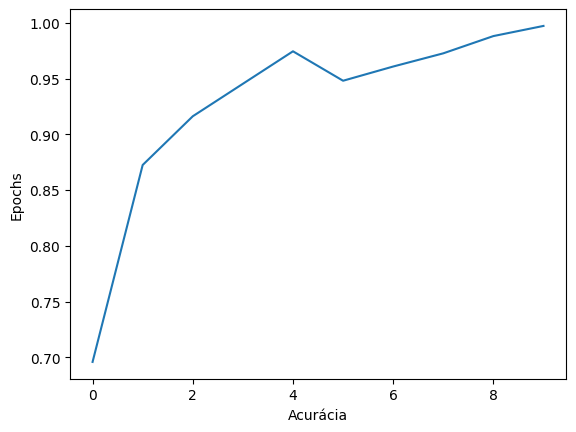

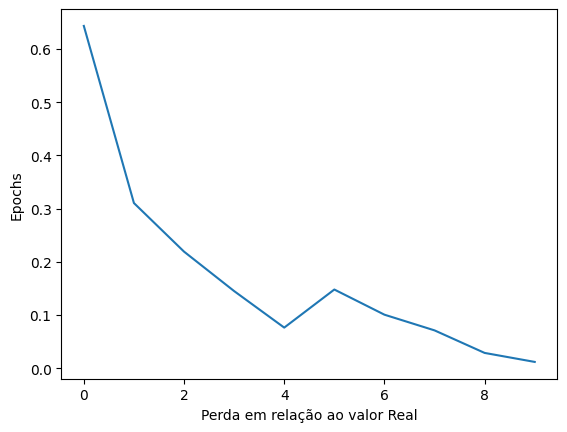

In [51]:
accuracy = history.history["accuracy"]
loss = history.history["loss"]

plt.figure()
plt.plot(accuracy, label="Evolução da Acurácia Durante Treinamento")
plt.ylabel("Epochs")
plt.xlabel("Acurácia")

plt.figure()
plt.plot(loss, label="Evolução da Precisão Durante Treinamento")
plt.ylabel("Epochs")
plt.xlabel("Perda em relação ao valor Real")